# Projeto do Sprint 8 — Recomendação de planos da Megaline


- `is_ultra = 1` → plano **Ultra**
- `is_ultra = 0` → plano **Smart**

## Objetivo

Alcançar a maior acurácia possível, ou seja, a maior porcentagem de acertos. O projeto exige no mínimo **0,75**, verificada no conjunto de teste.

## Dados

Arquivo: `datasets/users_behavior.csv`. Cada linha descreve o comportamento de um usuário ao longo de um mês.

| Coluna | Descrição |
|---|---|
| `calls` | número de chamadas |
| `minutes` | duração total das chamadas, em minutos |
| `messages` | número de mensagens de texto |
| `mb_used` | tráfego de internet usado, em MB |
| `is_ultra` | plano do mês atual (Ultra = 1, Smart = 0) — **variável-alvo** |

O pré-processamento desses dados já foi feito em um sprint anterior, então posso começar diretamente pela modelagem. Ainda assim, prefiro iniciar conferindo se está tudo certo com o arquivo.

## Plano de trabalho

1. Carregar e examinar os dados
2. Dividir os dados em treino, validação e teste (60% / 20% / 20%)
3. Testar três tipos de modelo, variando os hiperparâmetros e comparando os resultados na validação
4. Medir a qualidade do modelo escolhido no conjunto de teste
5. Tarefa adicional: fazer a prova real do modelo
6. Registrar as conclusões

## 1. Preparação

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score)

# semente única usada em todo o projeto, para garantir reprodutibilidade
RANDOM_STATE = 12345

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 4)

In [2]:
df = pd.read_csv('datasets/users_behavior.csv')
df.head()

,calls,minutes,messages,mb_used,is_ultra
0,40.0000,311.9000,83.0000,"19,915.4200",0
1,85.0000,516.7500,56.0000,"22,696.9600",0
2,77.0000,467.6600,86.0000,"21,060.4500",0
3,106.0000,745.5300,81.0000,"8,437.3900",1
4,66.0000,418.7400,1.0000,"14,502.7500",0


## 2. Exame dos dados

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     3214 non-null   float64
 1   minutes   3214 non-null   float64
 2   messages  3214 non-null   float64
 3   mb_used   3214 non-null   float64
 4   is_ultra  3214 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.7 KB


In [4]:
df.describe()

,calls,minutes,messages,mb_used,is_ultra
count,"3,214.0000","3,214.0000","3,214.0000","3,214.0000","3,214.0000"
mean,63.0389,438.2088,38.2813,"17,207.6738",0.3065
std,33.2364,234.5699,36.1483,"7,570.9682",0.4611
min,0.0000,0.0000,0.0000,0.0000,0.0000
25%,40.0000,274.5750,9.0000,"12,491.9025",0.0000
50%,62.0000,430.6000,30.0000,"16,943.2350",0.0000
75%,82.0000,571.9275,57.0000,"21,424.7000",1.0000
max,244.0000,"1,632.0600",224.0000,"49,745.7300",1.0000


In [5]:
print('Valores ausentes por coluna:')
print(df.isna().sum())
print()
print('Linhas duplicadas:', df.duplicated().sum())
print('Formato do conjunto:', df.shape)

Valores ausentes por coluna:
calls       0
minutes     0
messages    0
mb_used     0
is_ultra    0
dtype: int64

Linhas duplicadas: 0
Formato do conjunto: (3214, 5)


In [6]:
# 'calls' e 'messages' são contagens armazenadas como float — verificamos se há valor fracionário real
fracionarios = (df[['calls', 'messages']] % 1 != 0).sum()
print('Valores fracionários em colunas de contagem:')
print(fracionarios)

Valores fracionários em colunas de contagem:
calls       0
messages    0
dtype: int64


           contagem  proporcao
is_ultra                      
Smart (0)      2229     0.6935
Ultra (1)       985     0.3065


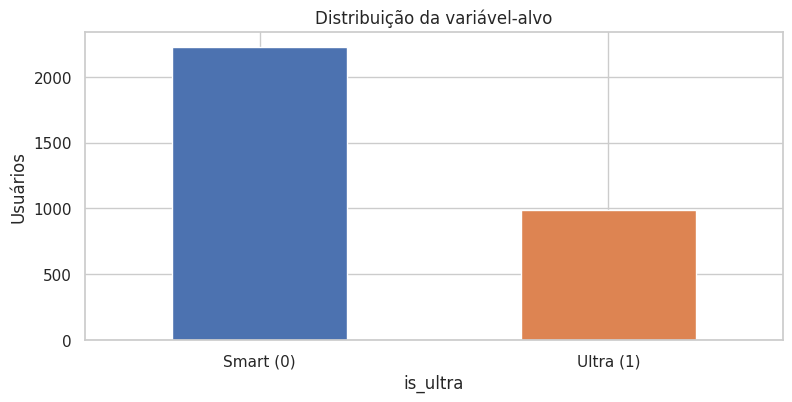

In [7]:
distribuicao = df['is_ultra'].value_counts().rename({0: 'Smart (0)', 1: 'Ultra (1)'})
proporcao = df['is_ultra'].value_counts(normalize=True).rename({0: 'Smart (0)', 1: 'Ultra (1)'})

print(pd.DataFrame({'contagem': distribuicao, 'proporcao': proporcao.round(4)}))

ax = distribuicao.plot(kind='bar', color=['#4C72B0', '#DD8452'], rot=0)
ax.set_title('Distribuição da variável-alvo')
ax.set_ylabel('Usuários')
plt.show()

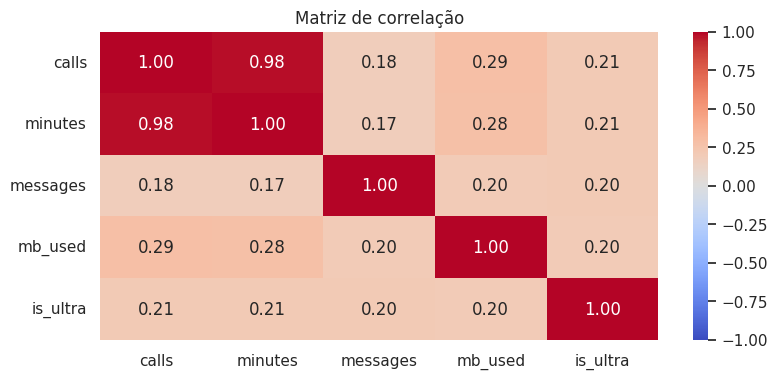

In [8]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Matriz de correlação')
plt.show()

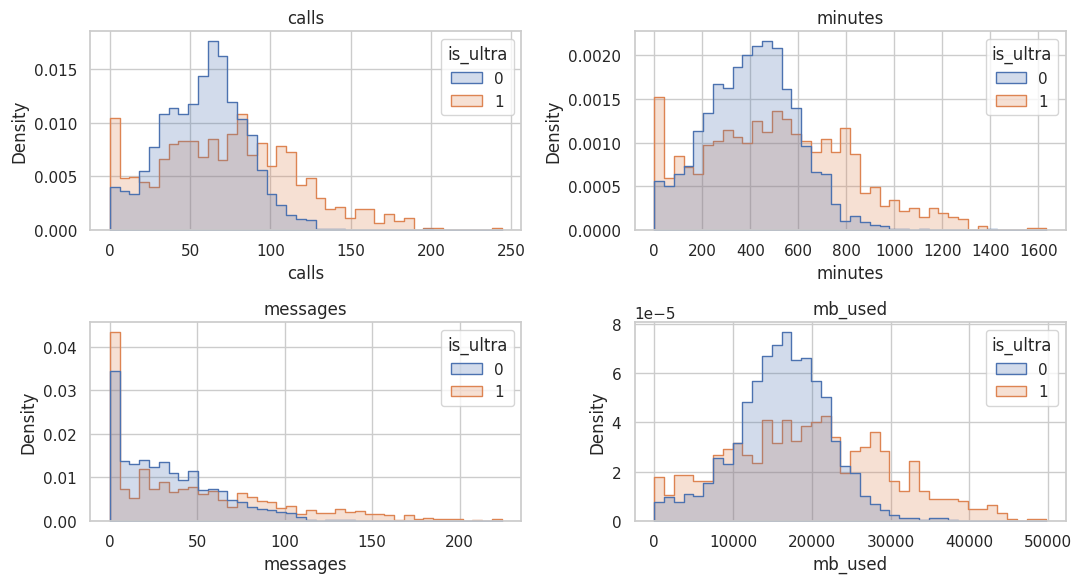

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, coluna in zip(axes.flatten(), ['calls', 'minutes', 'messages', 'mb_used']):
    sns.histplot(data=df, x=coluna, hue='is_ultra', bins=40, element='step',
                 stat='density', common_norm=False, ax=ax)
    ax.set_title(coluna)
plt.tight_layout()
plt.show()

### O que observei nos dados

- O conjunto tem **3.214 linhas e 5 colunas**, sem valores ausentes e sem linhas duplicadas. Ou seja, está limpo, como eu esperava, já que o tratamento foi feito no sprint anterior.
- As colunas `calls` e `messages` são contagens, mas estão armazenadas como `float64`. Conferi e não existe nenhum valor fracionário, então isso é apenas o tipo de armazenamento e não exige correção.
- As duas classes não aparecem na mesma quantidade: cerca de **69,4% dos usuários estão no Smart e 30,6% no Ultra**. Isso me trouxe duas preocupações:
  1. preciso dividir os dados de forma **estratificada**, para que essa mesma proporção apareça nos três conjuntos;
  2. a acurácia sozinha pode enganar, porque um modelo que respondesse sempre “Smart” já acertaria cerca de 69%. Por isso vou comparar o meu modelo com respostas automáticas desse tipo na seção 6.
- `calls` e `minutes` têm correlação de **0,98**, ou seja, carregam praticamente a mesma informação em unidades diferentes. Os modelos baseados em árvore lidam bem com isso, mas a regressão logística fica instável nesse cenário — mais um motivo para padronizar as variáveis antes de usá-la.
- Nenhuma coluna sozinha tem correlação forte com o alvo (todas ficam em torno de 0,20). Isso significa que **não existe uma regra simples de corte**, do tipo “quem usa mais de X MB é Ultra”. A resposta depende da combinação das quatro variáveis, o que favorece modelos capazes de capturar relações mais complexas.
- Os histogramas confirmam essa impressão: os usuários Ultra realmente consomem mais em todas as dimensões, mas as distribuições se sobrepõem bastante e não é possível separá-las com um único limite.

## 3. Divisão dos dados

O projeto pede **três conjuntos**, e o arquivo veio todo junto, então preciso repartir os 3.214 registros por conta própria.

**Proporção escolhida: 60% para treino, 20% para validação e 20% para teste.**

Por que escolhi assim:

- É a divisão mais comum quando não existe um conjunto de teste separado. Ela deixa a maior parte dos dados para o treino e ainda reserva validação e teste do mesmo tamanho, o que torna as duas medições comparáveis entre si.
- 20% equivalem a **643 registros** em cada conjunto. É uma quantidade suficiente para que a acurácia medida não varie muito por acaso. Se eu usasse 70/15/15, sobrariam apenas 482 registros para o teste e a estimativa ficaria mais instável.
- Como a função `train_test_split` divide os dados em duas partes de cada vez, faço a separação em **duas etapas**: primeiro separo 60% de treino e 40% temporários; depois divido esses 40% ao meio, chegando a 20% + 20%.
- Nas duas etapas uso `stratify`, para manter a proporção Smart/Ultra igual nos três conjuntos, e `random_state=12345`, para que qualquer pessoa que execute o notebook obtenha exatamente a mesma divisão.

In [10]:
features = df.drop('is_ultra', axis=1)
target = df['is_ultra']

# Etapa 1: 60% treino / 40% temporário
features_train, features_temp, target_train, target_temp = train_test_split(
    features, target, test_size=0.4, random_state=RANDOM_STATE, stratify=target)

# Etapa 2: divide o temporário ao meio -> 20% validação / 20% teste
features_valid, features_test, target_valid, target_test = train_test_split(
    features_temp, target_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=target_temp)

resumo = pd.DataFrame({
    'registros': [len(features_train), len(features_valid), len(features_test)],
    'proporcao_do_total': [len(features_train) / len(df),
                           len(features_valid) / len(df),
                           len(features_test) / len(df)],
    'proporcao_ultra': [target_train.mean(), target_valid.mean(), target_test.mean()]
}, index=['treino', 'validacao', 'teste'])

resumo.round(4)

,registros,proporcao_do_total,proporcao_ultra
treino,1928,0.5999,0.3065
validacao,643,0.2001,0.3064
teste,643,0.2001,0.3064


Os três conjuntos mantiveram cerca de 30,6% de usuários Ultra, o que confirma que a estratificação funcionou.

**Uma regra que vou seguir daqui em diante:** todos os hiperparâmetros serão escolhidos observando **apenas** o conjunto de validação. O conjunto de teste fica reservado até a seção 5 e será usado **uma única vez**. Se eu o consultasse a cada ajuste, ele deixaria de ser uma medida honesta do desempenho final.

## 4. Investigação da qualidade dos modelos

Vou testar três tipos de modelo. Para cada um deles, experimento várias combinações de hiperparâmetros — as configurações que eu defino antes do treinamento — e comparo os resultados no conjunto de validação.

| Modelo | Hiperparâmetros que vou variar |
|---|---|
| Árvore de decisão | `max_depth` de 1 a 20, `min_samples_leaf` em {1, 2, 4, 8} |
| Floresta aleatória | `n_estimators` de 10 a 100 (de 10 em 10), `max_depth` de 1 a 20 e sem limite |
| Regressão logística | `solver` em {liblinear, lbfgs}, `C` em {0.01, 0.1, 1, 10, 100} |

### 4.1 Árvore de decisão

In [11]:
resultados_arvore = []

for depth in range(1, 21):
    for min_leaf in [1, 2, 4, 8]:
        modelo = DecisionTreeClassifier(random_state=RANDOM_STATE,
                                        max_depth=depth,
                                        min_samples_leaf=min_leaf)
        modelo.fit(features_train, target_train)
        resultados_arvore.append({
            'max_depth': depth,
            'min_samples_leaf': min_leaf,
            'acuracia_treino': accuracy_score(target_train, modelo.predict(features_train)),
            'acuracia_validacao': accuracy_score(target_valid, modelo.predict(features_valid))
        })

resultados_arvore = pd.DataFrame(resultados_arvore)
melhor_arvore = resultados_arvore.loc[resultados_arvore['acuracia_validacao'].idxmax()]

print('Melhores 5 configurações (árvore de decisão):')
print(resultados_arvore.sort_values('acuracia_validacao', ascending=False).head(5).to_string(index=False))
print()
print(f"Melhor: max_depth={int(melhor_arvore['max_depth'])}, "
      f"min_samples_leaf={int(melhor_arvore['min_samples_leaf'])}, "
      f"acurácia de validação={melhor_arvore['acuracia_validacao']:.4f}")

Melhores 5 configurações (árvore de decisão):
 max_depth  min_samples_leaf  acuracia_treino  acuracia_validacao
         8                 1           0.8558              0.8025
         8                 4           0.8449              0.8009
         8                 8           0.8387              0.8009
         7                 8           0.8294              0.7994
         7                 4           0.8340              0.7978

Melhor: max_depth=8, min_samples_leaf=1, acurácia de validação=0.8025


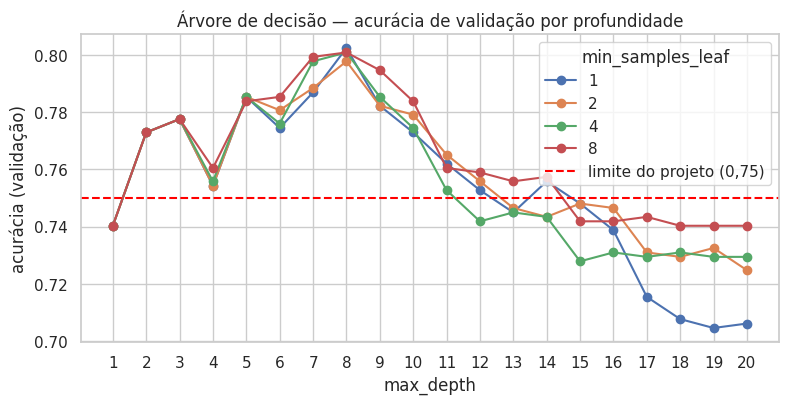

In [12]:
pivot_arvore = resultados_arvore.pivot(index='max_depth',
                                       columns='min_samples_leaf',
                                       values='acuracia_validacao')
pivot_arvore.plot(marker='o')
plt.axhline(0.75, color='red', linestyle='--', label='limite do projeto (0,75)')
plt.title('Árvore de decisão — acurácia de validação por profundidade')
plt.xlabel('max_depth')
plt.ylabel('acurácia (validação)')
plt.xticks(range(1, 21))
plt.legend(title='min_samples_leaf')
plt.show()

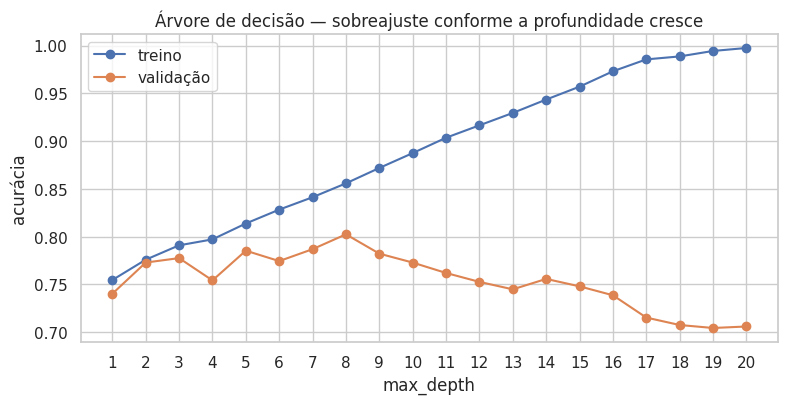

In [13]:
# Comparação treino vs validação para diagnosticar sobreajuste (min_samples_leaf = 1)
sub = resultados_arvore[resultados_arvore['min_samples_leaf'] == 1]
plt.plot(sub['max_depth'], sub['acuracia_treino'], marker='o', label='treino')
plt.plot(sub['max_depth'], sub['acuracia_validacao'], marker='o', label='validação')
plt.title('Árvore de decisão — sobreajuste conforme a profundidade cresce')
plt.xlabel('max_depth')
plt.ylabel('acurácia')
plt.xticks(range(1, 21))
plt.legend()
plt.show()

**O que os resultados da árvore me mostraram:** a acurácia na validação cresce até `max_depth` em torno de 7 ou 8 e depois começa a **cair**, enquanto a acurácia no treino continua subindo até chegar perto de 1,0. Esse afastamento entre as duas curvas é o sinal clássico de **sobreajuste**: a partir dessa profundidade a árvore deixa de aprender padrões gerais e passa a decorar os detalhes do conjunto de treino. Aumentar o `min_samples_leaf` torna a queda mais suave, porque obriga cada folha a conter mais exemplos, mas ainda assim não supera o melhor resultado obtido com árvores mais rasas.

### 4.2 Floresta aleatória

In [14]:
resultados_floresta = []

for n_est in range(10, 101, 10):
    for depth in list(range(1, 21)) + [None]:
        modelo = RandomForestClassifier(random_state=RANDOM_STATE,
                                        n_estimators=n_est,
                                        max_depth=depth,
                                        n_jobs=-1)
        modelo.fit(features_train, target_train)
        resultados_floresta.append({
            'n_estimators': n_est,
            'max_depth': depth if depth is not None else np.nan,
            'acuracia_treino': accuracy_score(target_train, modelo.predict(features_train)),
            'acuracia_validacao': accuracy_score(target_valid, modelo.predict(features_valid))
        })

resultados_floresta = pd.DataFrame(resultados_floresta)
melhor_floresta = resultados_floresta.loc[resultados_floresta['acuracia_validacao'].idxmax()]

print('Melhores 5 configurações (floresta aleatória):')
print(resultados_floresta.sort_values('acuracia_validacao', ascending=False).head(5).to_string(index=False))
print()
print(f"Melhor: n_estimators={int(melhor_floresta['n_estimators'])}, "
      f"max_depth={int(melhor_floresta['max_depth'])}, "
      f"acurácia de validação={melhor_floresta['acuracia_validacao']:.4f}")

Melhores 5 configurações (floresta aleatória):
 n_estimators  max_depth  acuracia_treino  acuracia_validacao
           40     9.0000           0.8833              0.8212
           30     8.0000           0.8703              0.8196
           80    12.0000           0.9118              0.8196
           70    12.0000           0.9108              0.8180
           50     9.0000           0.8833              0.8180

Melhor: n_estimators=40, max_depth=9, acurácia de validação=0.8212


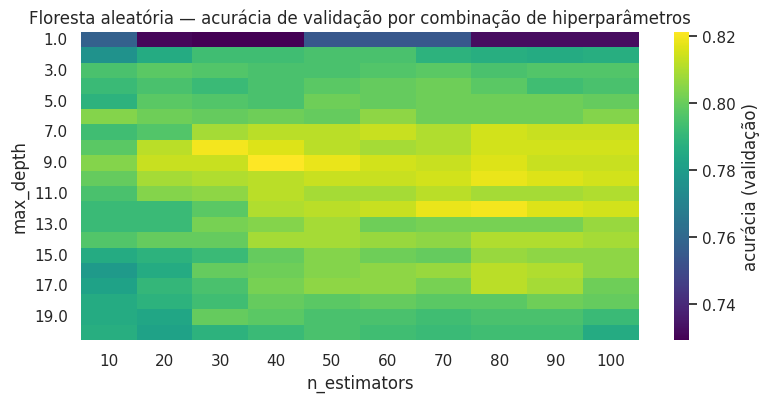

In [15]:
pivot_floresta = resultados_floresta.dropna(subset=['max_depth']).pivot(
    index='max_depth', columns='n_estimators', values='acuracia_validacao')

sns.heatmap(pivot_floresta, cmap='viridis', cbar_kws={'label': 'acurácia (validação)'})
plt.title('Floresta aleatória — acurácia de validação por combinação de hiperparâmetros')
plt.show()

**O que os resultados da floresta me mostraram:** o desempenho é visivelmente melhor do que o da árvore isolada, o que faz sentido, já que a floresta combina a resposta de várias árvores diferentes. O mapa de calor deixa claro que **a profundidade pesa muito mais do que a quantidade de árvores**: os melhores resultados se concentram entre `max_depth` 8 e 12, enquanto passar de aproximadamente 40 árvores quase não muda o resultado e apenas deixa o treinamento mais lento. Profundidades muito baixas causam subajuste, ou seja, o modelo fica simples demais; profundidades muito altas voltam a sobreajustar, ainda que de forma mais branda do que na árvore única.

### 4.3 Regressão logística

In [16]:
# As variáveis têm escalas muito diferentes (mb_used chega a ~50.000; calls a ~244),
# então a regressão logística entra dentro de um pipeline com padronização.
resultados_logistica = []

for solver in ['liblinear', 'lbfgs']:
    for C in [0.01, 0.1, 1, 10, 100]:
        modelo = make_pipeline(
            StandardScaler(),
            LogisticRegression(random_state=RANDOM_STATE, solver=solver, C=C, max_iter=1000)
        )
        modelo.fit(features_train, target_train)
        resultados_logistica.append({
            'solver': solver,
            'C': C,
            'acuracia_treino': accuracy_score(target_train, modelo.predict(features_train)),
            'acuracia_validacao': accuracy_score(target_valid, modelo.predict(features_valid))
        })

resultados_logistica = pd.DataFrame(resultados_logistica)
melhor_logistica = resultados_logistica.loc[resultados_logistica['acuracia_validacao'].idxmax()]

print(resultados_logistica.sort_values('acuracia_validacao', ascending=False).to_string(index=False))
print()
print(f"Melhor: solver={melhor_logistica['solver']}, C={melhor_logistica['C']}, "
      f"acurácia de validação={melhor_logistica['acuracia_validacao']:.4f}")

   solver        C  acuracia_treino  acuracia_validacao
liblinear   0.0100           0.7510              0.7434
liblinear   0.1000           0.7495              0.7418
liblinear   1.0000           0.7505              0.7387
liblinear  10.0000           0.7510              0.7387
liblinear 100.0000           0.7510              0.7387
    lbfgs   0.1000           0.7495              0.7387
    lbfgs  10.0000           0.7510              0.7387
    lbfgs   1.0000           0.7505              0.7387
    lbfgs 100.0000           0.7510              0.7387
    lbfgs   0.0100           0.7443              0.7325

Melhor: solver=liblinear, C=0.01, acurácia de validação=0.7434


**O que os resultados da regressão logística me mostraram:** todas as configurações chegam praticamente ao mesmo resultado (~0,74) e **nenhuma alcança o limite de 0,75** exigido pelo projeto. Alterar o parâmetro de regularização `C` quase não muda nada, o que me indica que o problema não está no ajuste do modelo, e sim na **suposição de que as duas classes podem ser separadas por uma reta**. Isso combina com o que eu já havia observado nos histogramas da seção 2: as classes se sobrepõem e a separação depende da combinação entre as variáveis, algo que os modelos de árvore conseguem capturar e a regressão logística não.

### 4.4 Comparação entre os modelos

In [17]:
comparacao = pd.DataFrame([
    {'modelo': 'Árvore de decisão',
     'melhores_hiperparametros': f"max_depth={int(melhor_arvore['max_depth'])}, min_samples_leaf={int(melhor_arvore['min_samples_leaf'])}",
     'acuracia_treino': melhor_arvore['acuracia_treino'],
     'acuracia_validacao': melhor_arvore['acuracia_validacao']},
    {'modelo': 'Floresta aleatória',
     'melhores_hiperparametros': f"n_estimators={int(melhor_floresta['n_estimators'])}, max_depth={int(melhor_floresta['max_depth'])}",
     'acuracia_treino': melhor_floresta['acuracia_treino'],
     'acuracia_validacao': melhor_floresta['acuracia_validacao']},
    {'modelo': 'Regressão logística',
     'melhores_hiperparametros': f"solver={melhor_logistica['solver']}, C={melhor_logistica['C']}",
     'acuracia_treino': melhor_logistica['acuracia_treino'],
     'acuracia_validacao': melhor_logistica['acuracia_validacao']},
]).sort_values('acuracia_validacao', ascending=False).reset_index(drop=True)

comparacao

,modelo,melhores_hiperparametros,acuracia_treino,acuracia_validacao
0,Floresta aleatória,"n_estimators=40, max_depth=9",0.8833,0.8212
1,Árvore de decisão,"max_depth=8, min_samples_leaf=1",0.8558,0.8025
2,Regressão logística,"solver=liblinear, C=0.01",0.7510,0.7434


### O que concluí desta etapa

1. **A floresta aleatória foi a melhor**, com cerca de 0,82 de acurácia na validação. É o modelo que levo para o teste final.
2. **A árvore de decisão** ficou logo atrás (~0,80). Ela treina muito mais rápido e é mais fácil de explicar, então seria uma boa alternativa caso houvesse alguma restrição de tempo ou de recurso computacional.
3. **A regressão logística** foi a única que **não alcançou o limite de 0,75**, reforçando que este problema não é linearmente separável.
4. Existe uma troca a ser feita: a floresta leva alguns segundos para treinar, contra milissegundos da árvore, em troca de cerca de 2 pontos percentuais de acurácia. Como a recomendação de planos seria feita em lote, e não em tempo real, esse custo não representa um problema e eu prefiro priorizar a acurácia.

## 5. Verificação da qualidade no conjunto de teste

Agora treino novamente o modelo vencedor com os hiperparâmetros escolhidos e o avalio **uma única vez** no conjunto de teste, que não participou de nenhuma decisão até este ponto.

In [18]:
modelo_final = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_estimators=int(melhor_floresta['n_estimators']),
    max_depth=int(melhor_floresta['max_depth']),
    n_jobs=-1
)
modelo_final.fit(features_train, target_train)

predicoes_teste = modelo_final.predict(features_test)
acuracia_teste = accuracy_score(target_test, predicoes_teste)

desempenho = pd.Series({
    'treino': accuracy_score(target_train, modelo_final.predict(features_train)),
    'validacao': accuracy_score(target_valid, modelo_final.predict(features_valid)),
    'teste': acuracia_teste
}, name='acuracia')

print(desempenho.round(4).to_string())
print()
print(f'Acurácia no conjunto de teste: {acuracia_teste:.4f}')
print(f'Limite exigido pelo projeto:   0.7500')
print('RESULTADO:', 'APROVADO' if acuracia_teste >= 0.75 else 'ABAIXO DO LIMITE')

treino      0.8833
validacao   0.8212
teste       0.8087

Acurácia no conjunto de teste: 0.8087
Limite exigido pelo projeto:   0.7500
RESULTADO: APROVADO


**Interpretação:** a acurácia no teste (~0,81) ficou **acima do limite de 0,75** exigido pelo projeto e muito próxima da acurácia de validação (~0,82). Essa proximidade é um bom sinal: mostra que a escolha dos hiperparâmetros **não se ajustou demais ao conjunto de validação** e que aquela estimativa era confiável.

Já a diferença entre treino (~0,88) e teste (~0,81) revela um sobreajuste residual. Isso é esperado em florestas aleatórias, porque cada árvore decora uma parte do conjunto de treino; a média entre elas, porém, continua generalizando bem.

## 6. Tarefa adicional — prova real do modelo

A acurácia sozinha não prova que o modelo aprendeu alguma coisa. Como 69,4% dos usuários estão no plano Smart, **um modelo que respondesse “Smart” para todos já acertaria cerca de 69%**. Para ter certeza de que o meu modelo faz mais do que isso, realizei três verificações:

1. comparar o modelo com respostas automáticas simples (`DummyClassifier`);
2. analisar a matriz de confusão e as métricas separadas por classe, e não apenas a média;
3. repetir a medição com validação cruzada, para verificar se o resultado se mantém.

In [19]:
baselines = {}
for estrategia in ['most_frequent', 'stratified', 'uniform']:
    dummy = DummyClassifier(strategy=estrategia, random_state=RANDOM_STATE)
    dummy.fit(features_train, target_train)
    baselines[estrategia] = accuracy_score(target_test, dummy.predict(features_test))

prova_real = pd.Series(baselines, name='acuracia_teste')
prova_real['MODELO FINAL (floresta aleatória)'] = acuracia_teste

print(prova_real.sort_values(ascending=False).round(4).to_string())
print()
ganho = acuracia_teste - baselines['most_frequent']
print(f'Ganho sobre o baseline mais forte (sempre "Smart"): {ganho:.4f} '
      f'({ganho * 100:.1f} pontos percentuais)')

MODELO FINAL (floresta aleatória)   0.8087
most_frequent                       0.6936
stratified                          0.5568
uniform                             0.4946

Ganho sobre o baseline mais forte (sempre "Smart"): 0.1151 (11.5 pontos percentuais)


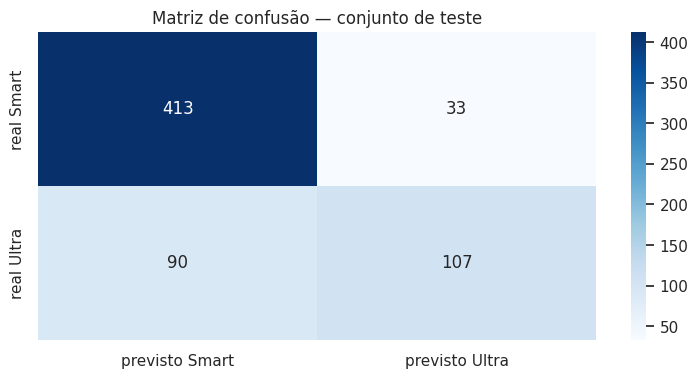

              precision    recall  f1-score   support

       Smart      0.821     0.926     0.870       446
       Ultra      0.764     0.543     0.635       197

    accuracy                          0.809       643
   macro avg      0.793     0.735     0.753       643
weighted avg      0.804     0.809     0.798       643



ROC-AUC: 0.85


In [20]:
matriz = confusion_matrix(target_test, predicoes_teste)

sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['previsto Smart', 'previsto Ultra'],
            yticklabels=['real Smart', 'real Ultra'])
plt.title('Matriz de confusão — conjunto de teste')
plt.show()

print(classification_report(target_test, predicoes_teste,
                            target_names=['Smart', 'Ultra'], digits=3))
print('ROC-AUC:', round(roc_auc_score(target_test, modelo_final.predict_proba(features_test)[:, 1]), 4))

In [21]:
# Estabilidade: validação cruzada em 5 dobras sobre treino + validação
features_cv = pd.concat([features_train, features_valid])
target_cv = pd.concat([target_train, target_valid])

scores = cross_val_score(
    RandomForestClassifier(random_state=RANDOM_STATE,
                           n_estimators=int(melhor_floresta['n_estimators']),
                           max_depth=int(melhor_floresta['max_depth']),
                           n_jobs=-1),
    features_cv, target_cv, cv=5, scoring='accuracy')

print('Acurácias por dobra:', np.round(scores, 4))
print(f'Média: {scores.mean():.4f}  |  Desvio padrão: {scores.std():.4f}')

Acurácias por dobra: [0.8117 0.7996 0.7977 0.7996 0.8171]
Média: 0.8051  |  Desvio padrão: 0.0078


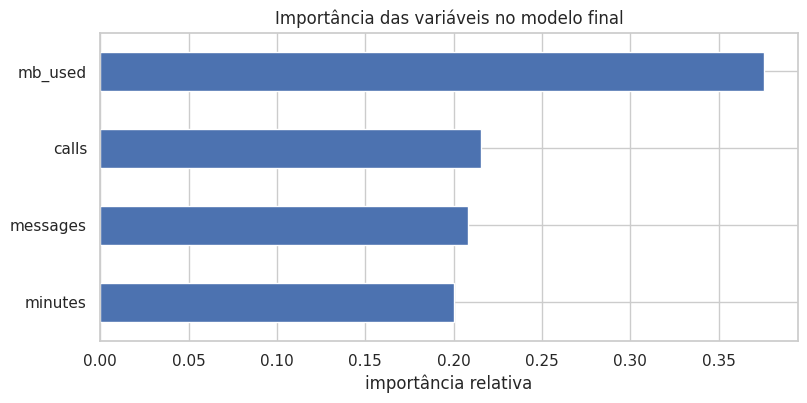

mb_used    0.3760
calls      0.2158
messages   0.2080
minutes    0.2002


In [22]:
importancias = pd.Series(modelo_final.feature_importances_,
                        index=features.columns).sort_values()

importancias.plot(kind='barh', color='#4C72B0')
plt.title('Importância das variáveis no modelo final')
plt.xlabel('importância relativa')
plt.show()

print(importancias.sort_values(ascending=False).round(4).to_string())

### Resultado da prova real

- **O modelo supera com folga as respostas automáticas.** A melhor delas (responder sempre “Smart”) chega a ~0,69, enquanto o meu modelo chega a ~0,81. Esses 11 a 12 pontos percentuais de diferença mostram que ele realmente utiliza o comportamento do usuário, e não apenas aproveita o fato de uma classe ser mais frequente.
- **O ROC-AUC de ~0,85** indica que o modelo consegue ordenar bem os usuários pela chance de serem Ultra. Para comparar: um modelo que respondesse ao acaso teria 0,50.
- **A matriz de confusão revela o ponto fraco do modelo.** Ele acerta quase sempre os usuários Smart (recall de ~0,93), mas identifica pouco mais da metade dos usuários Ultra (recall de ~0,54). Ou seja, quando erra, erra para o lado conservador: recomenda Smart para alguém que se beneficiaria do Ultra. Isso é consequência direta do desbalanceamento, já que a classe Ultra oferece menos exemplos para o modelo aprender.
- Por outro lado, a **precisão para a classe Ultra é alta (~0,76)**: quando o modelo recomenda Ultra, ele geralmente está certo. Pensando no negócio, isso é positivo, porque recomendar um plano mais caro sem necessidade gera atrito com o cliente, enquanto deixar de recomendar apenas mantém a situação atual.
- **A validação cruzada com 5 divisões** resultou em média de ~0,805, com desvio padrão de ~0,008. O resultado do teste está dentro dessa faixa, o que mostra que a acurácia obtida não foi sorte de uma divisão específica.
- As **importâncias das variáveis** apontam `mb_used` como a mais influente (~0,38), com as outras três em um patamar semelhante (~0,20 cada). Isso faz sentido, porque o consumo de internet é a principal diferença entre os dois planos.

## 7. Conclusão

**O objetivo foi alcançado: o modelo final chegou a ~0,81 de acurácia no conjunto de teste, acima do limite de 0,75 exigido pelo projeto.**

**Modelo escolhido:** floresta aleatória (`RandomForestClassifier`) com `n_estimators=40` e `max_depth=9`, treinada com 60% dos dados.

**O caminho que percorri:**

1. Os dados já estavam limpos (3.214 registros, sem nulos nem duplicatas), mas **desbalanceados** (69,4% Smart e 30,6% Ultra). Foi isso que me levou a usar divisões estratificadas e a comparar o modelo com respostas automáticas na prova real.
2. A divisão 60/20/20 estratificada garantiu a mesma composição de classes nos três conjuntos e um conjunto de teste com 643 registros, grande o suficiente para uma estimativa estável.
3. Entre os três modelos testados, a ordem de desempenho na validação foi: **floresta aleatória (~0,82) > árvore de decisão (~0,80) > regressão logística (~0,74)**. A regressão logística ficou abaixo do limite, o que mostra que o problema não é linearmente separável.
4. O hiperparâmetro mais importante foi a **profundidade**: nos dois modelos de árvore o desempenho sobe até `max_depth` em torno de 8 ou 9 e depois cai por sobreajuste. O número de árvores da floresta pouco alterou o resultado acima de 40.
5. No teste, o modelo alcançou **~0,81 de acurácia**, bem próximo do que eu havia observado na validação, sinal de que a escolha dos hiperparâmetros não comprometeu a estimativa.
6. Na prova real, o modelo superou a resposta automática “sempre Smart” em 11 a 12 pontos percentuais, com ROC-AUC de ~0,85 e validação cruzada estável (~0,805 ± 0,008).

**Limitações e próximos passos:**

- O **recall da classe Ultra (~0,54)** é a principal limitação. Se o objetivo da empresa fosse encontrar o maior número possível de candidatos ao Ultra, valeria a pena ajustar o **limiar de decisão** (usando `predict_proba` no lugar de `predict`) ou testar `class_weight='balanced'`, abrindo mão de um pouco de acurácia geral em troca de mais acertos na classe minoritária.
- `calls` e `minutes` carregam praticamente a mesma informação (correlação de 0,98). Remover uma das duas deixaria o modelo mais simples, sem perda relevante.
- O conjunto possui apenas quatro variáveis de comportamento e um único mês de observação. Acredito que novas variáveis, como tempo de contrato, histórico de faturas ou região, elevariam mais o teto de acurácia do que qualquer ajuste adicional de hiperparâmetros.